## **Experiment_02: Deep Feature Retrieval**

**Deep Feature Retrieval using Embeddings**

Experiment 01 showed that MSE and SSIM retrieve images mainly according to pixel alignment, global appearance, and camera viewpoint. In this experiment, we move from direct image comparison to feature-based retrieval.

Instead of comparing images pixel by pixel, each image is passed through a CNN feature extractor and represented as an embedding vector. Retrieval is then performed by comparing these embeddings using cosine similarity.

| Method | Description |
|---|---|
| [Pretrained ResNet Embeddings + Cosine Similarity](#resnet) | Uses a ResNet pretrained on ImageNet as a generic visual feature extractor. |
| [Task 2 CNN Embeddings + Cosine Similarity](#cnn) | Uses the CNN trained for ball counting as a task-specific feature extractor. |

Two feature extractors are evaluated:

1. **Pretrained ResNet (ImageNet)** – a generic visual representation learned from large-scale image classification.

2. **Task 2 CNN** – a billiard-specific network trained for ball counting, whose intermediate feature representations may capture information more relevant to table configurations.

The objective is to determine whether deep visual features provide a more meaningful retrieval representation than raw pixel similarity and whether task-specific features outperform generic pretrained features.

#### **Imports and paths**

In [ ]:
from pathlib import Path
import sys
import os
# import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

from torchvision import models
import torch.nn as nn
import torch

In [2]:
# Used in later experiments

# SEED = 42

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

In [3]:
PROJECT_ROOT = Path.cwd().parents[2]
DATA_DIR = PROJECT_ROOT / "data"
PARTITION_CSV = DATA_DIR / "partition.csv"
IMAGES_DIR = PROJECT_ROOT / "8-Ball Pool.v3i.yolov11" / "train" / "images"
RETRIEVAL_DIR = PROJECT_ROOT / "detection_and_retrieval" / "retrieval"
if str(RETRIEVAL_DIR) not in sys.path:
    sys.path.append(str(RETRIEVAL_DIR))
RESULTS_DIR = RETRIEVAL_DIR / "outputs" / "experiment_02"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert PARTITION_CSV.exists(), f"Missing partition CSV: {PARTITION_CSV}"
assert IMAGES_DIR.exists(), f"Missing images directory: {IMAGES_DIR}"

In [4]:
from utils.data import get_resnet_transform, load_retrieval_datasets, show_image, denormalize_image
from utils.setup import get_device

#### **Load Dataset**

The retrieval pool is composed of the training images, while the query set is composed of the test images, following the split defined in `partition.csv`.

Each image is resized, center-cropped, converted to tensor format, and normalized using ImageNet statistics, matching the preprocessing used in the baseline notebook.

In [5]:
transform = get_resnet_transform()

retrieval_pool, query_data = load_retrieval_datasets(
    images_dir=IMAGES_DIR,
    partition_csv=PARTITION_CSV,
    transform=transform
)

print(f"Retrieval pool size: {len(retrieval_pool)}")
print(f"Query set size: {len(query_data)}")

sample_img, sample_name = query_data[0]

print(f"Sample query filename: {sample_name}")
print(f"Sample query tensor shape: {sample_img.shape}")
print(f"Sample query tensor dtype: {sample_img.dtype}")

Retrieval pool size: 207
Query set size: 20
Sample query filename: 107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg
Sample query tensor shape: torch.Size([3, 224, 224])
Sample query tensor dtype: torch.float32


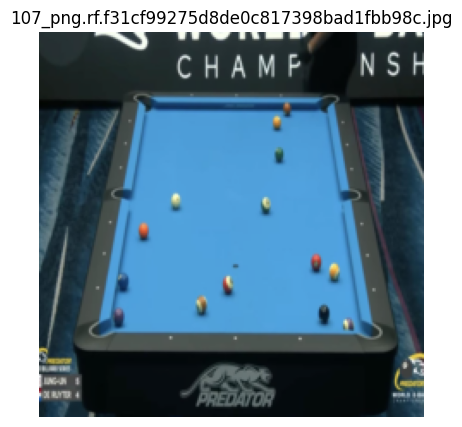

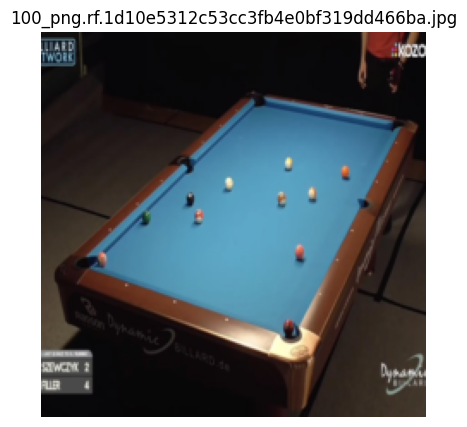

In [6]:
show_image(query_data, 0)
show_image(retrieval_pool, 1)

<a id="resnet"></a>
### **Pretrained ResNet Embeddings + Cosine Similarity**

Unlike MSE and SSIM, which compare images directly in pixel space, ResNet compares images in a learned feature space.

We use a ResNet pretrained on ImageNet as a feature extractor. The final classification layer is removed, and the activations of the last feature layer are used as image embeddings.

Retrieval is performed by:

1. **Extracting one embedding vector per image.**

2. **Computing cosine similarity between the query embedding and all retrieval-pool embeddings.**

3. **Ranking retrieval images according to similarity score.**

The expectation is that ResNet embeddings will be less sensitive to small pixel-level changes and may capture higher-level visual patterns than MSE or SSIM.

- #### **Load ResNet**

In [7]:
device = get_device()

Using mps


In [8]:
resnet = models.resnet50(weights="DEFAULT")

# Remove classification layer
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

- #### **Embedding extraction**

In [9]:
def extract_embedding(model, image_tensor):
    """
    Extract a ResNet embedding from a single image.
    """
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        embedding = model(image_tensor)
        embedding = embedding.flatten()

    return embedding.cpu().numpy()

- #### **Query Example**

In [10]:
query_image, query_name = query_data[0]

query_embedding = extract_embedding(
    feature_extractor,
    query_image
)

print(query_embedding.shape)

(2048,)


- #### **Cosine Similarity Computation**

In [11]:
def get_topk_resnet(query_image, retrieval_pool, model, k=5):

    query_embedding = extract_embedding(model, query_image)

    scores = np.zeros(len(retrieval_pool))

    for i in tqdm(range(len(retrieval_pool))):
        candidate_image, _ = retrieval_pool[i]

        candidate_embedding = extract_embedding(
            model,
            candidate_image
        )

        scores[i] = cosine_similarity(
            query_embedding.reshape(1, -1),
            candidate_embedding.reshape(1, -1)
        )[0, 0]

    topk_idx = np.argsort(scores)[::-1][:k]

    return topk_idx, scores

- #### **Query Retrieval Example**

We first evaluate the retrieval behaviour on a single query image.

For the selected query, we extract its ResNet embedding, compute cosine similarity against all retrieval-pool embeddings, and retrieve the Top-5 most similar images.

In [12]:
top5_resnet_idx, similarities_resnet = get_topk_resnet(
    query_image=query_image,
    retrieval_pool=retrieval_pool,
    model=feature_extractor,
    k=5
)

print("Top-5 ResNet results:")
for rank, idx in enumerate(top5_resnet_idx, start=1):
    _, name = retrieval_pool[idx]

    print(
        f"{rank}. {name} | Cosine similarity = {similarities_resnet[idx]:.4f}"
    )

100%|██████████| 207/207 [00:05<00:00, 37.83it/s]

Top-5 ResNet results:
1. 120_png.rf.ad88298a705a565adab2f06fe083c434.jpg | Cosine similarity = 0.9552
2. 25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg | Cosine similarity = 0.9546
3. 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg | Cosine similarity = 0.9539
4. 149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg | Cosine similarity = 0.9512
5. 132_png.rf.071b2e2111df71728a6b770afd959117.jpg | Cosine similarity = 0.9505


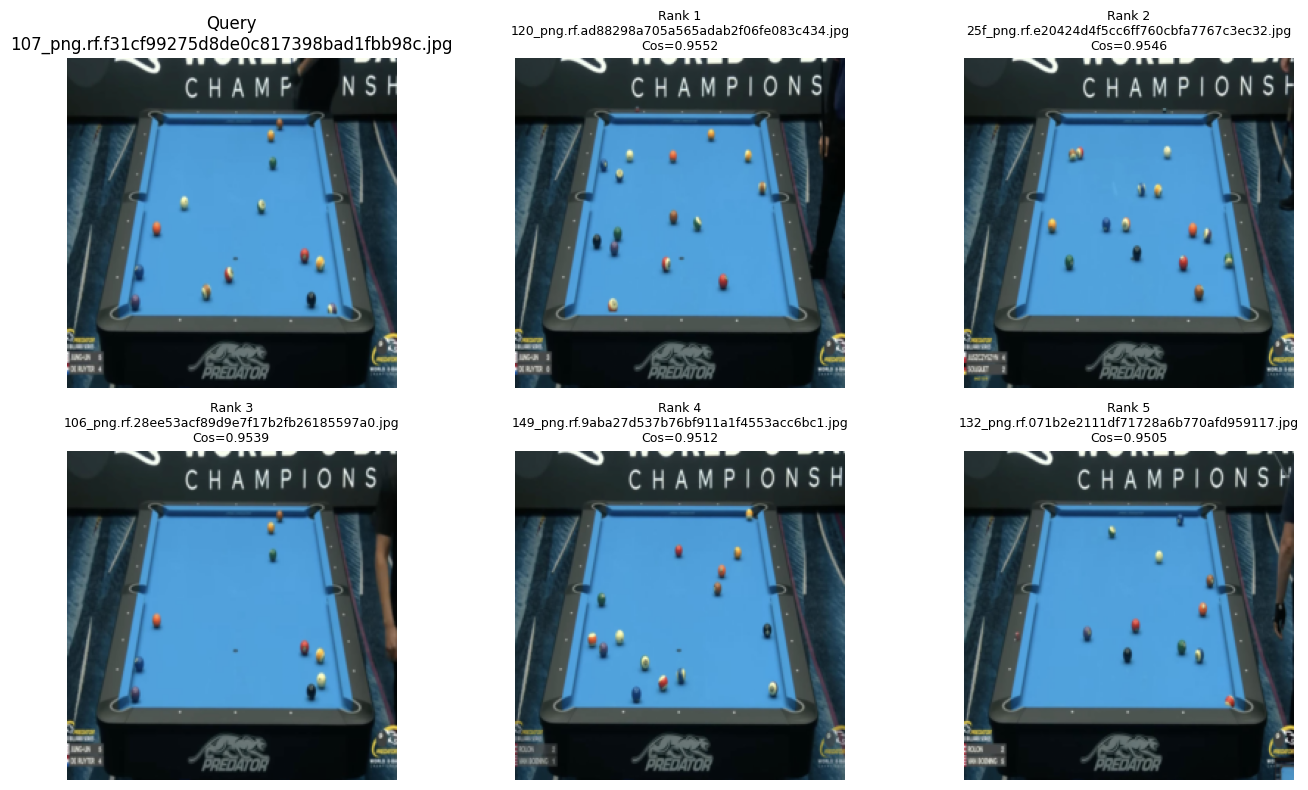

In [13]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(denormalize_image(query_image))
axarr[0][0].set_title(f"Query\n{query_name}")
axarr[0][0].axis("off")

for j in range(1, 6):

    idx = top5_resnet_idx[j - 1]

    img, name = retrieval_pool[idx]

    axarr[j // 3][j % 3].imshow(
        denormalize_image(img)
    )

    axarr[j // 3][j % 3].set_title(
        f"Rank {j}\n{name}\nCos={similarities_resnet[idx]:.4f}",
        fontsize=9
    )

    axarr[j // 3][j % 3].axis("off")

plt.tight_layout()
plt.show()

- #### **ResNet Observations**

    - Compared with MSE and SSIM, ResNet retrieves images based on higher-level visual features rather than direct pixel similarity.

    - The retrieved images consistently share the same broadcast-style viewpoint and table appearance.

    - Similarity appears to be influenced by global scene structure and overall table occupancy.

    - However, several top-ranked images exhibit substantially different ball configurations.

    - These results suggest that pretrained ResNet embeddings provide a richer visual representation than pixel-based methods but still do not explicitly encode billiard-table state.
    
    - Viewpoint bias remains present, motivating the evaluation of task-specific embeddings learned from the Task 2 CNN.

<a id="cnn"></a>
### **Task 2 CNN + Cosine Similarity**

The second feature-based retrieval approach uses the CNN trained for Task 2 as a task-specific feature extractor.

Unlike the pretrained ResNet, which learns generic ImageNet features, the Task 2 CNN is trained on billiard-table images for ball counting. Therefore, its intermediate representations may encode information related to the number of balls, their visual appearance, and possibly their spatial distribution.

Retrieval is performed using the same strategy as before:

1. **Load the trained Task 2 CNN.**

2. **Remove or bypass the final prediction layer.**

3. **Extract one embedding vector per image.**

4. **Compare embeddings using cosine similarity.**

The objective is to evaluate whether task-specific features provide better retrieval behaviour than generic ResNet features.

In [ ]:
# ============================================================
# TASK 2 CNN FEATURE EXTRACTOR
# ============================================================

# TODO:
# 1. Import or define the Task 2 CNN architecture.
# 2. Load trained Task 2 weights.
# 3. Remove/bypass the final prediction layer.
# 4. Use the remaining network as an embedding extractor.

### **Complete Retrieval**

To evaluate the ResNet embedding baseline on the full query set, we compute embeddings for all retrieval-pool images once and reuse them for every query.

This follows the standard retrieval pipeline:

1. **Offline phase:** compute and store embeddings for all training images.

2. **Query phase:** compute the query embedding, compare it with all stored embeddings, sort by cosine similarity, and return the Top-K results.

In [14]:
def compute_dataset_embeddings(dataset, model):
    embeddings = []
    filenames = []

    for img, name in tqdm(dataset):
        emb = extract_embedding(model, img)
        embeddings.append(emb)
        filenames.append(name)

    embeddings = np.vstack(embeddings)

    return embeddings, filenames


retrieval_embeddings, retrieval_filenames = compute_dataset_embeddings(
    retrieval_pool,
    feature_extractor
)

print(f"Retrieval embeddings shape: {retrieval_embeddings.shape}")
print(f"Number of retrieval filenames: {len(retrieval_filenames)}")

100%|██████████| 207/207 [00:05<00:00, 38.68it/s]

Retrieval embeddings shape: (207, 2048)
Number of retrieval filenames: 207


In [15]:
def get_topk_from_embeddings(query_image, model, retrieval_embeddings, k=5):
    query_embedding = extract_embedding(model, query_image)

    scores = cosine_similarity(
        query_embedding.reshape(1, -1),
        retrieval_embeddings
    )[0]

    topk_idx = np.argsort(scores)[::-1][:k]

    return topk_idx, scores

In [16]:
K = 5

resnet_results = []

for query_idx in tqdm(range(len(query_data))):
    query_image, query_name = query_data[query_idx]

    topk_idx, scores = get_topk_from_embeddings(
        query_image=query_image,
        model=feature_extractor,
        retrieval_embeddings=retrieval_embeddings,
        k=K
    )

    row = {
        "query_idx": query_idx,
        "query_name": query_name,
    }

    for rank in range(K):
        retrieved_idx = topk_idx[rank]
        retrieved_name = retrieval_filenames[retrieved_idx]

        row[f"resnet_rank{rank+1}_name"] = retrieved_name
        row[f"resnet_rank{rank+1}_score"] = scores[retrieved_idx]

    resnet_results.append(row)

resnet_results_df = pd.DataFrame(resnet_results)

resnet_results_df.head()

100%|██████████| 20/20 [00:00<00:00, 33.68it/s]


,query_idx,query_name,resnet_rank1_name,resnet_rank1_score,resnet_rank2_name,resnet_rank2_score,resnet_rank3_name,resnet_rank3_score,resnet_rank4_name,resnet_rank4_score,resnet_rank5_name,resnet_rank5_score
0,0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.955244,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.954643,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.953915,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.951196,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.950479
1,1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.915575,21a_png.rf.34ea0016904d75da861731071be2058f.jpg,0.910906,108_png.rf.7bd2f9160e38391af93d2d6ebaaf966a.jpg,0.909395,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.905041,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.904419
2,2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.963124,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.960888,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.951633,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.949733,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.949125
3,3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.896179,169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg,0.893586,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.889938,172_png.rf.fcfccb64edd6563c971ed5aadc369851.jpg,0.887837,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.885578
4,4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.976536,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.975640,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.974655,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.974345,8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg,0.973711


In [17]:
results_path = RESULTS_DIR / "retrieval_results_resnet.csv"

resnet_results_df.to_csv(results_path, index=False)

print(f"Saved ResNet retrieval results to: {results_path}")

Saved ResNet retrieval results to: /Users/sarataboas/Desktop/master/2_semester/computer_vision/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_02/retrieval_results_resnet.csv


In [18]:
resnet_summary = resnet_results_df[
    [
        "query_name",
        "resnet_rank1_name",
        "resnet_rank1_score",
        "resnet_rank2_name",
        "resnet_rank2_score",
        "resnet_rank3_name",
        "resnet_rank3_score",
        "resnet_rank4_name",
        "resnet_rank4_score",
        "resnet_rank5_name",
        "resnet_rank5_score",
    ]
]

resnet_summary

,query_name,resnet_rank1_name,resnet_rank1_score,resnet_rank2_name,resnet_rank2_score,resnet_rank3_name,resnet_rank3_score,resnet_rank4_name,resnet_rank4_score,resnet_rank5_name,resnet_rank5_score
0,107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.955244,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.954643,106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg,0.953915,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.951196,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.950479
1,111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.915575,21a_png.rf.34ea0016904d75da861731071be2058f.jpg,0.910906,108_png.rf.7bd2f9160e38391af93d2d6ebaaf966a.jpg,0.909395,4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg,0.905041,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.904419
2,115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg,119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg,0.963124,25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg,0.960888,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.951633,145_png.rf.223f80e4aff2b64f2711cd186532e118.jpg,0.949733,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.949125
3,118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg,162_png.rf.faeb269d920f46126201519c32565e6d.jpg,0.896179,169_png.rf.db5c4e716dac3be45044ffb904f0202d.jpg,0.893586,166_png.rf.2a5fbe9b778584d26692a480bda6f22a.jpg,0.889938,172_png.rf.fcfccb64edd6563c971ed5aadc369851.jpg,0.887837,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.885578
4,134_png.rf.eafc70891a991c969df70bd817a63375.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.976536,6t_png.rf.3bfa7c04f03519e61d659108c308de32.jpg,0.975640,131_png.rf.593310c39f8835ed0786033b6690de45.jpg,0.974655,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.974345,8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg,0.973711
5,136_png.rf.e99c3dfd6e84ce294cdabc3bb5ee8a75.jpg,150_png.rf.d73327d3ac59114d003f79ec28e80c36.jpg,0.978099,7t_png.rf.d593f52ab7cb17881fddcaf5de468819.jpg,0.972867,147_png.rf.f75092db32c867f5974bd801ebff4919.jpg,0.971586,138_png.rf.8f90a2d90a20d34006c446dc14a852c0.jpg,0.969092,159_png.rf.301cd8292389a32360fcde7abf681cfe.jpg,0.968883
6,140_png.rf.6645e10bad5cf3f197b71ddb6b34e6b4.jpg,142_png.rf.7094e2d69746d686d71b971d474ae84d.jpg,0.972351,132_png.rf.071b2e2111df71728a6b770afd959117.jpg,0.966510,120_png.rf.ad88298a705a565adab2f06fe083c434.jpg,0.965896,133_png.rf.a4164ecd79cdd480304adcf094cd17e3.jpg,0.962568,149_png.rf.9aba27d537b76bf911a1f4553acc6bc1.jpg,0.961736
7,144_png.rf.5c3890791bfecba0869eafb73fa3a4f5.jpg,143_png.rf.4ddb999b17c98b304ca30654dfd0b01c.jpg,0.984656,125_png.rf.746e605d23baaa43560542b8554b714c.jpg,0.982082,124_png.rf.1c7ed97791213cc079fccc558f1ad959.jpg,0.979297,5t_png.rf.8e895b792f2cfabbbbaf6eb62c6e2622.jpg,0.978936,159_png.rf.301cd8292389a32360fcde7abf681cfe.jpg,0.978860
8,181_png.rf.23ccd3b4b31a6fef484f7f0d25cf89d7.jpg,178_png.rf.5087fa5324451e07d2ed4f3d0e39b8e7.jpg,0.891688,188_png.rf.817e806abd4f5edc9588cc0dbf1a8616.jpg,0.873900,141_png.rf.29f059d54b07ead4d4680ae0a8a66ec4.jpg,0.870546,164_png.rf.adf1d66e8c2fa71261ca3f1d6852fa16.jpg,0.852762,177_png.rf.44e0980f0a0137fa46f4a9ac8c51e603.jpg,0.850576
9,185_png.rf.d2a971d3a33d7f290e313be493525277.jpg,187_png.rf.b5c19d9e137330a99f4a5885ac5c7d73.jpg,0.904161,154_png.rf.9667f3add0f6a1d344745423a5d13882.jpg,0.891944,178_png.rf.5087fa5324451e07d2ed4f3d0e39b8e7.jpg,0.891147,170_png.rf.41755d44f9afc99e7cda8ff7b064d3e5.jpg,0.883443,160_png.rf.6f41e2456edd6888c9fae22813acc55e.jpg,0.883140


### **Experiment 02 Conclusion**

Write Conclusions after obtaining the CNN embedding retrieval